**Práctica 2** Procesamiento de dataset.

*Introducción a Ciencia de Datos*

***María Guadalupe Villanueva Utrilla***

**Descripción y procedencia de dataset**

El dataset empleado para esta primer práctica ha sido recolectado por la empresa Airbnb, la cual contiene datos recabados de las experiencias de los clientes en la Ciudad de México, expresado en fecha 15 de junio de 2026. Este dataset está compuesto por 31431 registros, cada una caracterizada con un respectivo id. Está conformado por algunos de los siguientes atributos: *id, listing_url, scrape_id, last_scraped, source, name, description, neighborhood_overview, picture_url, host_id, host_url, host_profile_id, host_profile_url, host_name, host_since, hosts_time_as_user_years, hosts_time_as_user_months, etc*.




**Estos datos han sido recolectados por Inside Airbnb**

(https://insideairbnb.com/get-the-data/); con listado individual como unidad de observación.


## Licencia y Atribución
Los datos utilizados en este proyecto provienen de [Inside Airbnb](https://insideairbnb.com/) y están protegidos bajo la licencia [Creative Commons Attribution 4.0 International License (CC BY 4.0)](https://creativecommons.org/licenses/by/4.0/).

* Cita: *Inside Airbnb. (2026). Mexico City, Distrito Federal, Mexico listings data (15 June 2026).*


En esta práctica se emplea información de alojamientos de Airbnb en Ciudad de México. Se realiza una exploración general del dataset y después se aplican los siguientes tres tipos de procesamiento:

1. limpieza de datos,
2. extracción de características,
3. reducción de dimensionalidad.

In [10]:
from pathlib import Path as path                               # para buscar archivos en la carpeta
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler as standardscaler   # para estandarizar las variables
from sklearn.decomposition import PCA as pca                       # reducción de dimensionalidad

pd.set_option("display.max_columns", 30)

In [11]:
df = pd.read_csv("listings.csv")        # carga el dataset precargado en el notebook

print("filas:", df.shape[0])
print("columnas:", df.shape[1])

df.head()

filas: 31430
columnas: 90


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,host_url,host_profile_id,host_profile_url,host_name,host_since,...,last_review,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,1698274831948209016,https://www.airbnb.com/rooms/1698274831948209016,20260615212254,2026-06-16,city scrape,Roma Residence | Luxury Suite 305,"Discover Condesa Residence Luxury Suites, excl...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,471105419,https://www.airbnb.com/users/show/471105419,1.470125e+18,https://www.airbnb.com/users/profile/147012479...,Manuel,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,42,42,0,0,NaN
1,1120444645818769896,https://www.airbnb.com/rooms/1120444645818769896,20260615212254,2026-06-17,city scrape,Grande y bonita habitación con cocina y baño,Disconnect from your worries in this spacious ...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,548898239,https://www.airbnb.com/users/show/548898239,1.470455e+18,https://www.airbnb.com/users/profile/147045548...,Catu,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,0,0,NaN
2,1414477907775396874,https://www.airbnb.com/rooms/1414477907775396874,20260615212254,2026-06-17,city scrape,Ven a sentirte como en casa.,Relax with the whole family at this peaceful p...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,49281983,https://www.airbnb.com/users/show/49281983,1.465751e+18,https://www.airbnb.com/users/profile/146575051...,Mireya,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN
3,1298027147444763745,https://www.airbnb.com/rooms/1298027147444763745,20260615212254,2026-06-17,city scrape,Habitación pequeña 16,You'll be close to everything if you stay in t...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,368484187,https://www.airbnb.com/users/show/368484187,1.469744e+18,https://www.airbnb.com/users/profile/146974393...,Gerardo,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN
4,1680714857095865427,https://www.airbnb.com/rooms/1680714857095865427,20260615212254,2026-06-16,city scrape,Quadruple Suite with Bathroom,Quad Suite – 1 Bathroom<br />Sleeps up to 4 gu...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1680682785801540826,https://www.airbnb.com/users/show/168068278580...,1.680683e+18,https://www.airbnb.com/users/profile/168068294...,Halinka,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,0,2,0,NaN


### Revisión

Aquí se llama al archivo, también se muestran las primeras filas para reconocer la estructura del dataset y sus respectivas columnas. El dataset contiene 31,430 registros y 90 columnas. En las primeras filas se puede ver que incluye información del alojamiento, del anfitrión, ubicación, precio, disponibilidad y  las reseñas

## Análisis exploratorio

Antes de procesar los datos se va a revisar qué columnas existen, qué tipos de datos tienen y cuáles tienen valores faltantes. También se estudian algunas variables importantes para conocer de forma general cómo está compuesto el conjunto.

tipos de datos más comunes:
float64    44
object     28
int64      18
Name: count, dtype: int64

Columnas con más valores faltantes:


,Faltantes
neighborhood_overview,31430
host_since,31430
host_response_time,31430
host_thumbnail_url,31430
host_acceptance_rate,31430
host_response_rate,31430
host_verifications,31430
neighbourhood,31430
host_total_listings_count,31430
host_neighbourhood,31430



Registros duplicados: 0


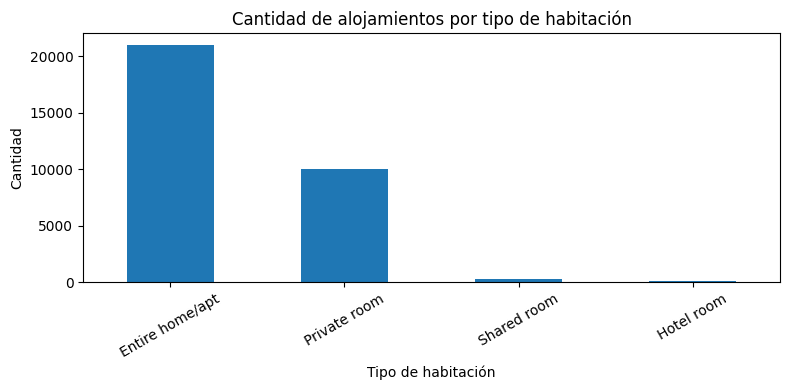

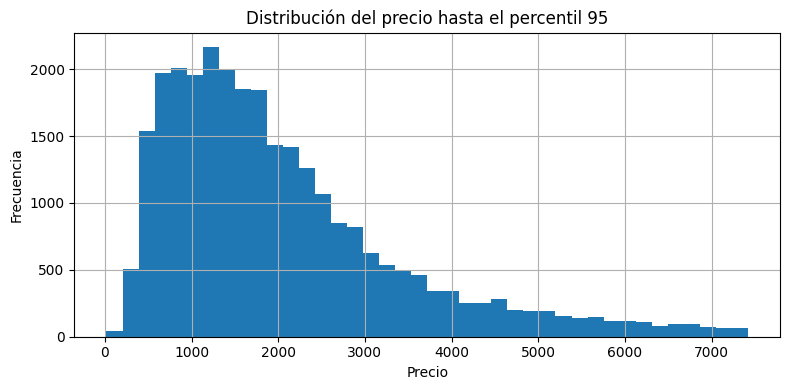

In [12]:
print("tipos de datos más comunes:")
print(df.dtypes.value_counts())

faltantes = df.isna().sum().sort_values(ascending=False).head(12)              # columnas con muchos faltantes
print("\nColumnas con más valores faltantes:")
display(faltantes.to_frame("Faltantes"))

print("\nRegistros duplicados:", df.duplicated().sum())

if "room_type" in df.columns:
    plt.figure(figsize=(8, 4))
    df["room_type"].value_counts().plot(kind="bar")
    plt.title("Cantidad de alojamientos por tipo de habitación")
    plt.xlabel("Tipo de habitación")
    plt.ylabel("Cantidad")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

if "price" in df.columns:
    precio_exploracion = pd.to_numeric(
        df["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False),
        errors="coerce")                                                       # convierte el precio a número

    limite_visual = precio_exploracion.quantile(0.95)       # evita que pocos precios extremos escocndan la forma general

    plt.figure(figsize=(8, 4))
    precio_exploracion[precio_exploracion <= limite_visual].hist(bins=40)
    plt.title("Distribución del precio hasta el percentil 95")
    plt.xlabel("Precio")
    plt.ylabel("Frecuencia")
    plt.tight_layout()
    plt.show()

### Revisión

Hay que ver que el dataset mezcla variables numéricas y categóricas y que no todas las columnas están completas. En este tipo de información es normal encontrar que los campos que son opcionales referentes al anfitrión o del alojamiento con valores faltantes. La gráfica de tipos de habitación ayuda a ver cuáles categorías tienen mayoría, mientras que la distribución del precio muestra que existen valores tan altos que pueden afectar la escala de la visualización

Se encontraron 44 variables de tipo decimal, 28 de texto y 18 enteras. Se nota que varias columnas tienen todos sus valores faltantes por lo que no serán útiles para un análisis. No hay registros duplicados. Para el tipo de alojamiento, hay muchos más alojamientos completos y las habitaciones privadas que habitaciones de hotel o compartidas.

## Técnica 1: limpieza de datos

Se maneja principalmente por el precio. Esta columna puede venir con formatos variados o que complican el estudio, por lo que se asegura que no suceda. También se van a eliminar los duplicados, registros sin información necesaria y valores muy dispersos de precio.

Se usa el intervalo entre los percentiles 1 y 99 porque deja retirar casos muy extremos sin quitar una parte demasiado grande del conjunto de datos

filas antes de limpiar: 31430
filas después de limpiar: 29044
registros retirados: 2386
precio mínimo conservado: 337.79
precio máximo conservado: 20269.13


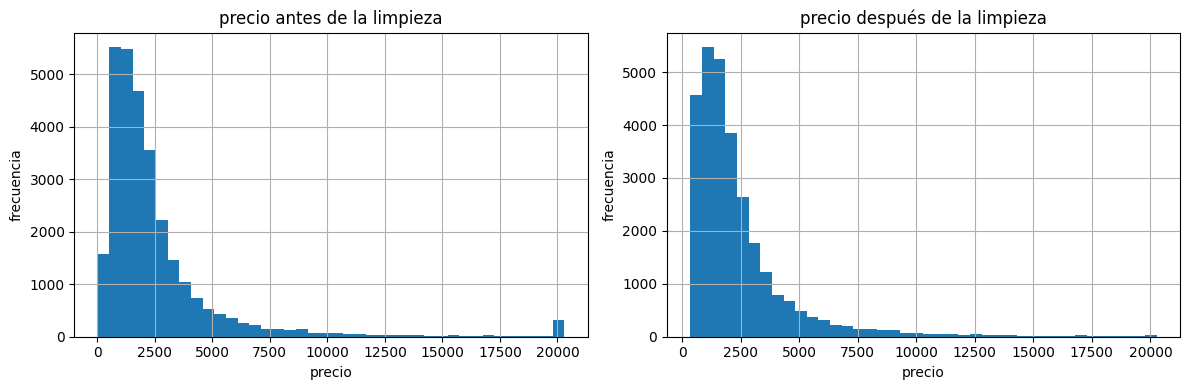

In [23]:
df_limpio = df.copy()                                                           # conserva intacto el dataframe original

df_limpio["price"] = pd.to_numeric(
    df_limpio["price"].astype(str).str.replace("$", "", regex=False).str.replace(",", "", regex=False),
    errors="coerce")                                                                                # transforma el precio de texto a número

precio_antes = df_limpio["price"].copy()

filas_iniciales = len(df_limpio)
df_limpio = df_limpio.drop_duplicates()                                          # elimina filas exactamente repetidas
df_limpio = df_limpio.dropna(subset=["price", "accommodates"])                   # conserva registros útiles para el análisis
df_limpio = df_limpio[df_limpio["accommodates"] > 0]

limite_inferior = df_limpio["price"].quantile(0.01)
limite_superior = df_limpio["price"].quantile(0.99)

df_limpio = df_limpio[
    df_limpio["price"].between(limite_inferior, limite_superior)
].copy()                                                                          # retira precios extremadamente bajos o altos

print("filas antes de limpiar:", filas_iniciales)
print("filas después de limpiar:", len(df_limpio))
print("registros retirados:", filas_iniciales - len(df_limpio))
print("precio mínimo conservado:", round(df_limpio["price"].min(), 2))
print("precio máximo conservado:", round(df_limpio["price"].max(), 2))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

precio_antes.dropna().clip(upper=precio_antes.quantile(0.99)).hist(bins=40, ax=ejes[0])
ejes[0].set_title("precio antes de la limpieza")
ejes[0].set_xlabel("precio")
ejes[0].set_ylabel("frecuencia")

df_limpio["price"].hist(bins=40, ax=ejes[1])
ejes[1].set_title("precio después de la limpieza")
ejes[1].set_xlabel("precio")
ejes[1].set_ylabel("frecuencia")

plt.tight_layout()
plt.show()

### Revisión
Después de la limpieza, el precio queda como una variable numérica que puede utilizarse sin problema en cálculos y gráficas. También se quitan los registros duplicados, filas sin precio o capacidad y casos de precio muy extremos. La comparación nos deja observar una distribución con menos dominio de los valores atípicos. Esto se hace, pues los extremos pueden distorsionar las medidas como el promedio y también afectar técnicas posteriores.

Después de hacer la limpieza, el número de registros pasó de 31,430 a 29,044, por lo que se eliminaron 2,386 registros entre valores faltantes, datos no utilizables y precios extremos. El rango de precios que se conservó quedó aproximadamente entre 338 y 20,269. La distribución mantiene una forma similar a la inicial, pero ya no tan afectada por los valores más extremos

## técnica 2: extracción de características

El precio total de un alojamiento no siempre es comparable entre propiedades con capacidades diferentes. Por esta razón se construirá una nueva variable llamada `price_per_person`, dividiendo el precio entre el número máximo de huéspedes.

Esta característica permite comparar alojamientos desde una perspectiva más proporcional.

          price  accommodates  price_per_person
count  29044.00      29044.00          29044.00
mean    2426.91          3.42            781.90
std     2346.02          2.29            733.32
min      337.79          1.00             21.38
25%     1084.88          2.00            409.40
50%     1756.00          3.00            600.50
75%     2826.25          4.00            902.61
max    20269.13         16.00          20039.00


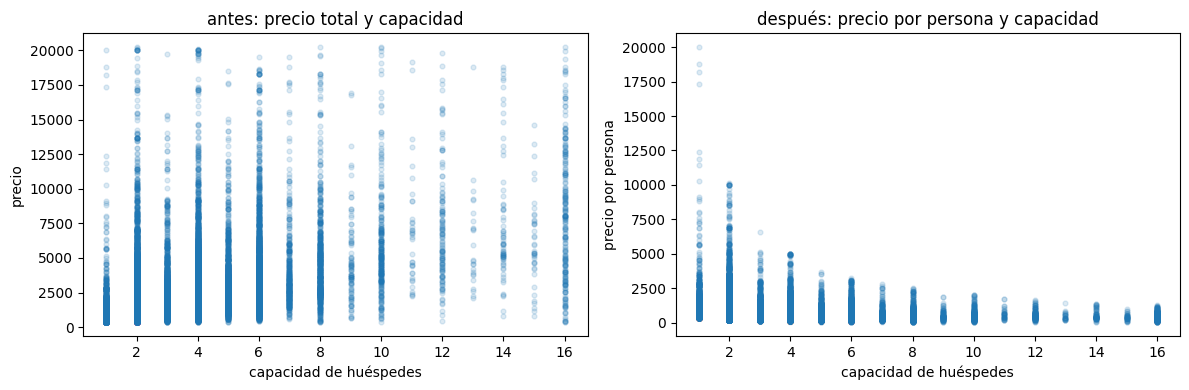

In [42]:
df_caracteristicas = df_limpio.copy()

df_caracteristicas["price_per_person"] = (
    df_caracteristicas["price"] / df_caracteristicas["accommodates"])                                                                                # calcula el precio aproximado por huésped

print(
    df_caracteristicas[["price", "accommodates", "price_per_person"]]
    .describe()
    .round(2))

fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

ejes[0].scatter(
    df_caracteristicas["accommodates"],
    df_caracteristicas["price"],
    alpha=0.15,
    s=12)
ejes[0].set_title("antes: precio total y capacidad")
ejes[0].set_xlabel("capacidad de huéspedes")
ejes[0].set_ylabel("precio")

ejes[1].scatter(
    df_caracteristicas["accommodates"],
    df_caracteristicas["price_per_person"],
    alpha=0.15,
    s=12)
ejes[1].set_title("después: precio por persona y capacidad")
ejes[1].set_xlabel("capacidad de huéspedes")
ejes[1].set_ylabel("precio por persona")

plt.tight_layout()
plt.show()

### revisión

El precio total suele aumentar cuando un alojamiento admite a más personas, por lo que comparar únicamente esa variable puede ser engañoso. Al calcular el precio por persona se reduce parte de ese efecto y resulta más sencillo comparar alojamientos de tamaños diferentes. La nueva característica no reemplaza al precio original, pero agrega información que puede ser útil en análisis posteriores.

Después de crear la variable ''price_per_person'' se puede comparar el precio de los alojamientos tomando en cuenta su capacidad. En la gráfica original se observa que alojamientos con mayor capacidad pueden alcanzar precios totales muy altos. Después de dividir el precio entre el número de huéspedes, se ve que el costo por persona tiende a bajar conforme aumenta la capacidad del alojamiento

## Técnica 3: Selección de características

Inside Airbnb trae muchas columnas que no se necesitan para un análisis como este, tales como urls, ids, textos largos, nombres, entre otros

In [69]:
variables_seleccionadas = [
    "price",
    "accommodates",
    "bedrooms",
    "beds",
    "room_type",
    "number_of_reviews",
    "review_scores_rating",
    "availability_365",
    "price_per_person"]

variables_seleccionadas = [
    col for col in variables_seleccionadas
    if col in df_caracteristicas.columns]                                                                               # conserva solo columnas disponibles

df_seleccionado = df_caracteristicas[variables_seleccionadas].copy()            # crea un dataframe reducido

print("columnas antes:", df_caracteristicas.shape[1])
print("columnas después:", df_seleccionado.shape[1])
print("variables seleccionadas:")
print(variables_seleccionadas)

df_seleccionado.head()

columnas antes: 91
columnas después: 9
variables seleccionadas:
['price', 'accommodates', 'bedrooms', 'beds', 'room_type', 'number_of_reviews', 'review_scores_rating', 'availability_365', 'price_per_person']


,price,accommodates,bedrooms,beds,room_type,number_of_reviews,review_scores_rating,availability_365,price_per_person
0,2066.00,4,1.0,1.0,Entire home/apt,0,NaN,365,516.50
1,628.00,2,1.0,1.0,Entire home/apt,0,NaN,257,314.00
2,499.00,2,NaN,2.0,Private room,0,NaN,158,249.50
3,2511.00,1,1.0,1.0,Private room,0,NaN,365,2511.00
4,8263.24,4,2.0,3.0,Private room,0,NaN,365,2065.81


## Revisión

Se seleccionaron solo las variables más relacionadas con las características del alojamiento como su capacidad, precio, reseñas y disponibilidad. Se descartan las columnas que no son necesarias para este análisis como ids, enlaces o textos descriptivos. Con esta selección se obtiene un conjunto manejable

De las 91 variables disponibles después de crear la nueva característica, se conservaron solo 9 para el análisis

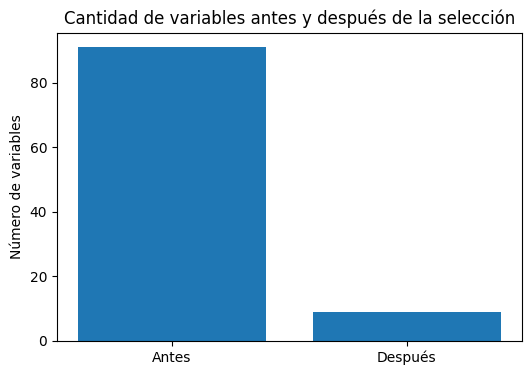

In [77]:
cantidades = [
    df_caracteristicas.shape[1],
    df_seleccionado.shape[1]]

plt.figure(figsize=(6, 4))
plt.bar(["Antes", "Después"], cantidades)
plt.title("Cantidad de variables antes y después de la selección")
plt.ylabel("Número de variables")

plt.show()

## Revisión

Se muestra cómo cambió el conjunto dando los datos antes y después de la selección de características. La comparación muestra una reducción pasando de 91 a 9 variables.

## técnica 4: reducción de dimensionalidad

El dataset contiene muchas variables y varias de ellas tiene características ralacionadas entre sí. Para una representación más compacta se emplea PCA a un grupo de variables numéricas.

Antes de usar PCA relleno los valores faltantes con la mediana y se estandarizan las variables. La estandarización se hace porque las columnas están medidas en escalas muy diferentes.

In [89]:
variables_pca = [
    col for col in df_seleccionado.columns
    if col != "room_type"]                                                                               # pca requiere variables numéricas

datos_pca = df_seleccionado[variables_pca].copy()

datos_pca = datos_pca.apply(
    pd.to_numeric,
    errors="coerce")                                                                                # asegura que las columnas sean numéricas

datos_pca = datos_pca.fillna(
    datos_pca.median())                                                                                # completa faltantes con la mediana

escalador = standardscaler()

datos_escalados = escalador.fit_transform(
    datos_pca)                                                                                # coloca las variables en una escala comparable

modelo_pca = pca(n_components=2)

componentes = modelo_pca.fit_transform(
    datos_escalados)                                                                                # reduce las variables a dos componentes

pca_df = pd.DataFrame(
    componentes,
    columns=["pc1", "pc2"])

print(
    "Varianza expresada por los dos componentes:",
    round(modelo_pca.explained_variance_ratio_.sum() * 100, 2),
    "%"
)

pca_df.head()

Varianza expresada por los dos componentes: 54.53 %


,pc1,pc2
0,-0.514820,-0.060745
1,-1.225924,-0.489645
2,-0.922968,-0.730464
3,-1.008719,2.324847
4,1.748349,2.632862


### Revisión

Antes de PCA, cada eje representa una variable específica y solo se pueden observar dos variables a la vez. Después de aplicarlo, los dos ejes son combinaciones de varias características originales. El porcentaje mostrado dice cuánta variación del conjunto puede resumirse con esos dos componentes. Aunque se puede perder parte de la interpretación directa de cada variable, se ve más compacta la estructura general de los datos


Después de PCA, los dos primeros componentes principales explicann el 54.53 % de la variación presente en las variables numéricas seleccionadas. Esto es más de la mitad de la información del conjunto que puede representarse utilizando solamente dos dimensiones pero todavía hay una parte grande de la variación que no queda representada con estos componentes

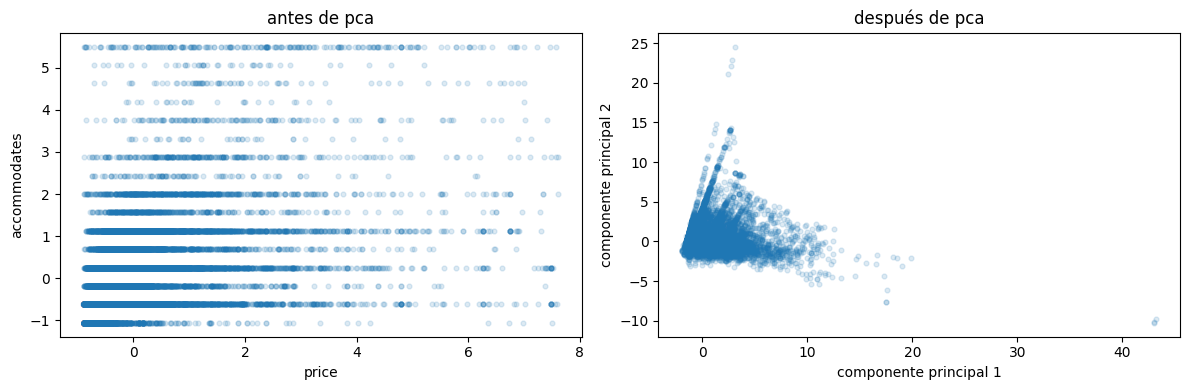

In [95]:
fig, ejes = plt.subplots(1, 2, figsize=(12, 4))

ejes[0].scatter(
    datos_escalados[:, 0],
    datos_escalados[:, 1],
    alpha=0.15,
    s=12)

ejes[0].set_title("antes de pca")
ejes[0].set_xlabel(variables_pca[0])
ejes[0].set_ylabel(variables_pca[1])

ejes[1].scatter(
    pca_df["pc1"],
    pca_df["pc2"],
    alpha=0.15,
    s=12)

ejes[1].set_title("después de pca")
ejes[1].set_xlabel("componente principal 1")
ejes[1].set_ylabel("componente principal 2")

plt.tight_layout()
plt.show()

## Revisión

En la gráfica de la izquierda solo se ven dos variables originales. En la gráfica de la derecha se muestran los dos componentes dados con PCA los cuales resumen información de todas las variables numéricas seleccionadas. Esto nos deja representar el conjunto de datos en dos dimensiones sin trabajar de manera directa con todas las columnas al mismo tiempo

Para el caso anteriior la gráfica nada más permite comparar directamente dos variables originales. Después de que se hace la reducción cada punto queda representado mediante dos componentes que combinan información de varias características. La mayoría de los alojamientos se focalizan en una misma región pero también hay registros alejados del grupo principal

## Conclusión


Las técnicas empleadas en este estudio muestran que el procesamiento previo no se basa solamente en eliminar datos, sino  que también se reorganizan y crean representaciones que para facilitar su análisis, dependiendo de los objetivos de tu análisis. Para este dataset no se usa aumento de datos porque ya existe una cantidad grande de registros y generar observaciones artificiales no era necesario.

Se aplicaron cuatro técnicas de procesamiento al dataset de Inside Airbnb de Ciudad de México. Primero, la limpieza logró reducir el conjunto de 31,430 a 29,044 registros y eliminar datos incompletos o valores de precio demasiado extremos que podían afectar los valores no dominantes. Después, mediante extracción de características se creó el precio por persona, lo que ayudó a comparar de una manera más justa alojamientos con capacidades de huéspedes diferentes. La selección de características redujo las variables de 91 a 9 y se conservaron las más relacionadas con el alojamiento y su precio. AL final PCA representró las variables numéricas seleccionadas mediante dos componentes que explican el 54.53 % de su variación

**Declaración sobre el uso de inteligencia artificial**

Para la realización de esta práctica se utilizó *Gemini (Google AI*) como herramienta de soporte técnico, pedagógico y de redacción.
Alcance de uso:
* Soporte de código y resolución de errores
* Comprensión de licencias.
* Supervisión de formato de texto.

*ChatGPT* ayudó a identificar qué variable crear para que el análisis los precios por habitación se vieran mejor distribuidos por cantidad de huéspedes.

